In [1]:
import os
from glob import glob

# --- Define Paths ---
base_path = "/kaggle/input/ghandinagar-rooftop-segmentation-dataset"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# --- Helper to pair files ---
def get_pairs(folder_path):
    # Find all JPG images
    img_files = sorted(glob(os.path.join(folder_path, "*.jpg")))
    pairs = []
    
    for img_p in img_files:
        # Construct expected mask path based on your pattern: 
        # "filename.jpg" -> "filename.jpg_mask.png"
        mask_p = img_p[:-4] + "_mask.png"
        
        if os.path.exists(mask_p):
            pairs.append((img_p, mask_p))
        else:
            # print(f"⚠️ Missing mask for: {os.path.basename(img_p)}")
            print(img_p)
            print(mask_p)
            
    return pairs

train_pairs = get_pairs(train_path)
test_pairs = get_pairs(test_path)

print(f"--- Training Set ---")
print(f"Found {len(train_pairs)} valid image-mask pairs.")

print(f"--- Test Set ---")
print(f"Found {len(test_pairs)} valid image-mask pairs.")

--- Training Set ---
Found 516 valid image-mask pairs.
--- Test Set ---
Found 60 valid image-mask pairs.


In [2]:
from PIL import Image
import numpy as np

if train_pairs:
    # Load the first pair
    sample_img_path, sample_mask_path = train_pairs[0]
    
    img = np.array(Image.open(sample_img_path))
    mask = np.array(Image.open(sample_mask_path))
    
    print(f"File: {os.path.basename(sample_img_path)}")
    print(f"Image Shape: {img.shape}")  # (Height, Width, 3)
    print(f"Mask Shape:  {mask.shape}")  # (Height, Width)
    
    print(f"Image Range: {img.min()} - {img.max()}")
    print(f"Mask Range:  {mask.min()} - {mask.max()}")
    
    # Check unique values to confirm binary vs grayscale
    unique_vals = np.unique(mask)
    print(f"Unique Values in Mask: {unique_vals}")
    
    if len(unique_vals) == 2:
        print("ℹ️ Binary Mask (likely 0=background, 255=rooftop or 0/1)")
    elif len(unique_vals) > 2:
        print("ℹ️ Warning: Mask contains multiple values (aliasing or multi-class).")

File: sample_0_jpg.rf.4e644d9a9813cce20ae1206c171d2154.jpg
Image Shape: (1024, 1024, 3)
Mask Shape:  (1024, 1024)
Image Range: 0 - 255
Mask Range:  0 - 1
Unique Values in Mask: [0 1]
ℹ️ Binary Mask (likely 0=background, 255=rooftop or 0/1)


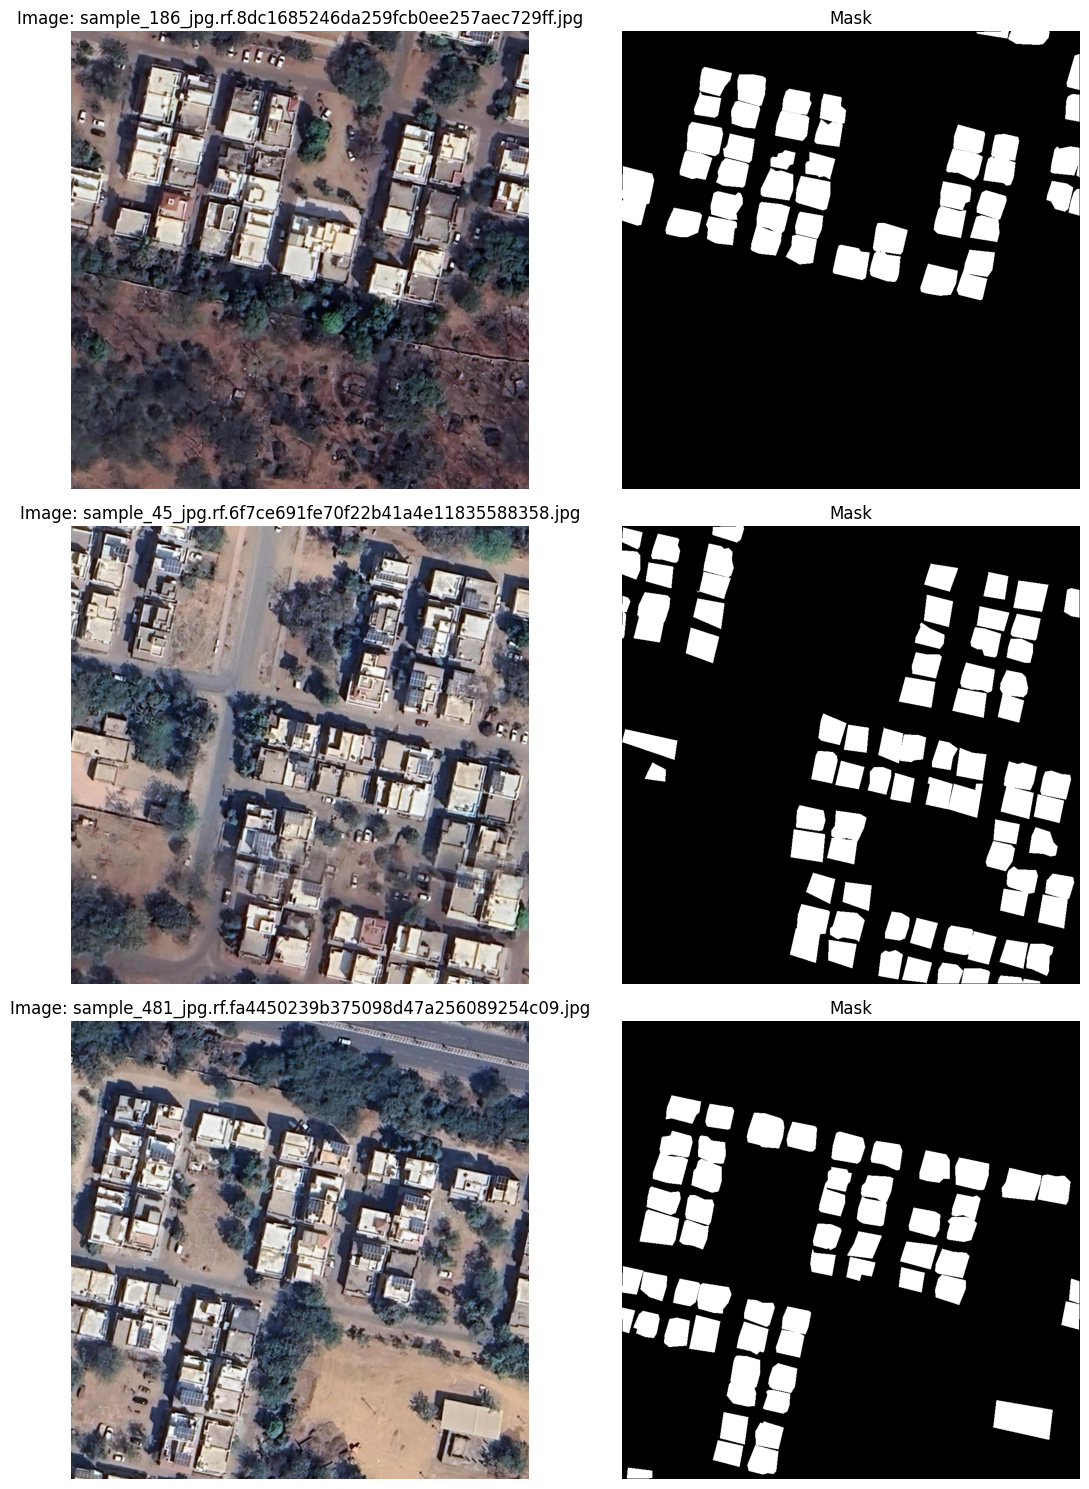

In [3]:
import matplotlib.pyplot as plt
import random

def plot_ghandinagar_samples(pairs, num_samples=3):
    if not pairs:
        print("No pairs to plot.")
        return

    plt.figure(figsize=(12, 5 * num_samples))
    
    # Pick random indices
    indices = random.sample(range(len(pairs)), min(len(pairs), num_samples))
    
    for i, idx in enumerate(indices):
        img_path, mask_path = pairs[idx]
        filename = os.path.basename(img_path)
        
        img = np.array(Image.open(img_path))
        mask = np.array(Image.open(mask_path))
        
        # Plot Image
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(img)
        plt.title(f"Image: {filename}")
        plt.axis("off")
        
        # Plot Mask
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Mask")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Visualize Training Data
plot_ghandinagar_samples(train_pairs)

In [4]:
# Analyze a subset of training data
subset_size = 20 
indices = random.sample(range(len(train_pairs)), min(len(train_pairs), subset_size))

rooftop_pixels = 0
total_pixels = 0

print(f"Calculating stats on {len(indices)} images...")

for idx in indices:
    _, mask_path = train_pairs[idx]
    mask = np.array(Image.open(mask_path))
    
    # Assuming > 0 is rooftop (works for 1 or 255)
    rooftop_pixels += np.sum(mask > 0)
    total_pixels += mask.size

if total_pixels > 0:
    ratio = (rooftop_pixels / total_pixels) * 100
    print(f"Total Pixels: {total_pixels}")
    print(f"Rooftop Pixels: {rooftop_pixels}")
    print(f"Rooftop Ratio: {ratio:.2f}%")
    print(f"Background Ratio: {100 - ratio:.2f}%")

Calculating stats on 20 images...
Total Pixels: 20971520
Rooftop Pixels: 3674950
Rooftop Ratio: 17.52%
Background Ratio: 82.48%
